# Bimanual Planning Example Notebook

This notebook demonstrates the complete workflow for planning constrained bimanual motions using the minimal coordinates strategy.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Fix relative paths so contents of the src directory can be imported.
import sys
sys.path.append("..")
sys.path.append("../../constrained-bimanual-planning-example")

In [3]:
import numpy as np
import os
import time
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import networkx as nx
import torch

In [4]:
from pydrake.all import (
    StartMeshcat,
    CollisionCheckerParams,
    RobotDiagramBuilder,
    MeshcatVisualizerParams,
    Role,
    MeshcatVisualizer,
    Parser,
    LoadModelDirectives,
    ProcessModelDirectives,
    SceneGraphCollisionChecker,
    AutoDiffXd,
    RigidTransform_,
    IrisNp2Options,
    IrisZoOptions,
    SnoptSolver,
    IpoptSolver,
    IrisParameterizationFunction,
    MathematicalProgram,
    HPolyhedron,
    IrisNp2,
    IrisZo,
    Hyperellipsoid,
    RandomGenerator,
    ComputePairwiseIntersections,
    GcsTrajectoryOptimization,
    Point,
    GraphOfConvexSetsOptions,
    FunctionHandleTrajectory,
    InitializeAutoDiff,
    ExtractGradient,
    Toppra,
    PathParameterizedTrajectory,
    PiecewisePolynomial,
    CompositeTrajectory,
    CalcGridPointsOptions,
    BsplineBasis,
    BsplineTrajectory,
    KinematicTrajectoryOptimization,
    MinimumDistanceLowerBoundConstraint,
    PyFunctionConstraint,
    SolverOptions,
    CommonSolverOption,
    Solve,
    sqrt,
    DiagramBuilder,
    TrajectorySource,
    InverseDynamicsController,
    Demultiplexer,
)

In [5]:
# We replace the analytic_ik with the NN
import src.iiwa_analytic_ik as iiwa_analytic_ik
import src.common as common
import src.rrt as rrt
import src.shortcut as shortcut
import src.utils as utils
from src.iiwa_program import Iiwa14IKProgram, IiwaFK
from ikflow.config import DEVICE
from jrl.math_utils import rotation_matrix_to_quaternion


ikflow/config.py | Using device: 'cuda:0'


The meshcat visualization can be viewed in your browser, by opening the link that appears after running the following cell.

In [6]:
# Only run this cell once.
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7000


# Parameters

- `directives_file` is a scene description, giving the location of all the models in the world.
- `grasp_distance` is the distance between the end-effectors of the two robot arms.
- `GC2`, `GC4`, and `GC6` are the "global configuration parameters", describing which branch of the IK function to use.
- `q_tilde_bottom`, `q_tilde_middle`, and `q_tilde_top` are three key configurations that we plan between, represented in the parameterized coordinates.
- `seeds` is a list of configurations to use as seed points for the region generation. They were chosen by hand, using a virtual teleoperation notebook, similar to [this one](https://deepnote.com/workspace/Manipulation-ac8201a1-470a-4c77-afd0-2cc45bc229ff/project/0762b167-402a-4362-9702-7d559f0e73bb/notebook/iris_builder-3c25c10bc29d4c9493e48eaced475d03). One can also generate regions to cover a graph in configuration space (shown later in the code for RRT) or use the [clique covers approach](https://ieeexplore.ieee.org/abstract/document/10610005/).

In [7]:
directives_file = os.path.join(common.RepoDir(), "models/old_shelves.dmd.yaml")
grasp_distance = 0.6
q_tilde_bottom = np.array([-0.6430910102907225,1.9156121024586796,-1.7968254667817805,1.2945447141185198,-0.023834531305537934,-0.876966810663043,-1.7041643160834519,-1.3065268517353166,1.658130679618188,-0.11816404512856976,-0.6801782039968504,0.6663830820319143,-0.4607197873885533,-1.3342584714027534,-1.3467175057975553])
q_tilde_middle = np.array([-0.5997312520566763, 1.489780849654964, -1.4739679827359913, 1.2905366081785483, -0.04421061906813227, -0.8793712572715165, -1.1603461715511334, 1.45])
q_tilde_top = np.array([-0.1994994216078726, 0.9140739951190965, -2.236618320862171, 0.5238879195899456, 0.7998441913611017, -1.3575398006936048, -1.0153092816310436, -0.1724197671774095, 0.09183837492938327, 1.0675584570477854, -1.0616344482718332, 0.21734820797221702, 0.11781950435342614, -1.68411089296333, -1.1857552653505647])

# Set Up Environment

This is general, boilerplate code that most Drake projects include. Note the usage of [`RobotDiagramBuilder`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1planning_1_1_robot_diagram_builder.html) to construct a [`RobotDiagram`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1planning_1_1_robot_diagram.html) and [`CollisionChecker`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1planning_1_1_collision_checker.html), as opposed to the less specific [`DiagramBuilder`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1systems_1_1_diagram_builder.html). We specifically use a [`SceneGraphCollisionChecker`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1planning_1_1_scene_graph_collision_checker.html).

In [8]:
params = CollisionCheckerParams()
builder = RobotDiagramBuilder(time_step=0.0)

meshcat_visual_params = MeshcatVisualizerParams()
meshcat_visual_params.delete_on_initialization_event = False
meshcat_visual_params.role = Role.kIllustration
meshcat_visual_params.prefix = "visual"
meshcat_visual = MeshcatVisualizer.AddToBuilder(
    builder.builder(), builder.scene_graph(), meshcat, meshcat_visual_params)

meshcat_collision_params = MeshcatVisualizerParams()
meshcat_collision_params.delete_on_initialization_event = False
meshcat_collision_params.role = Role.kProximity
meshcat_collision_params.prefix = "collision"
meshcat_collision_params.visible_by_default = False
meshcat_collision = MeshcatVisualizer.AddToBuilder(
    builder.builder(), builder.scene_graph(), meshcat, meshcat_collision_params)

plant = builder.plant()
parser = Parser(plant)
package_xml_path = os.path.join(common.RepoDir(), "package.xml")
parser.package_map().AddPackageXml(package_xml_path)
directives = LoadModelDirectives(directives_file)
ProcessModelDirectives(directives, parser)

params.robot_model_instances = [
    plant.GetModelInstanceByName("iiwa_left"),
    plant.GetModelInstanceByName("iiwa_right")
]

plant.Finalize()

# We export these inputs and outputs so we can wrap the RobotDiagram in a larger
# Diagram, which will include a controller, to simulate and visualize.
builder.builder().ExportInput(plant.get_actuation_input_port(), "actuation")
builder.builder().ExportOutput(plant.get_state_output_port(), "state")

diagram = builder.Build()

params.model = diagram
params.edge_step_size = 0.01
checker = SceneGraphCollisionChecker(params)

context = diagram.CreateDefaultContext()
plant_context = plant.GetMyContextFromRoot(context)
diagram.ForcedPublish(context)

INFO:drake:Allocating contexts to support implicit context parallelism 8


## Set Up the Parameterization

Check out `src/iiwa_analytic_ik.py` for more details on the implementation of the analytic IK function itself. The key special aspect needed for this project is making it compatible with both `float` and Drake's `AutoDiffXd` scalar type (or numpy arrays of each). When called with `AutoDiffXd`, it will automatically perform forward-mode automatic differentiation. Care must be taken to return objects of the correct template type -- see [this documentation](https://drake.mit.edu/python_bindings.html#c-function-and-method-template-instantiations-in-python) for more information on how Drake handles templating in Python.

The parameterization has two parts, the callable function itself, and the [`IrisParameterizationFunction`](https://drake.mit.edu/doxygen_cxx/classdrake_1_1planning_1_1_iris_parameterization_function.html) object, which wraps the callable and maintains some additional necessary information (input dimension and thread safety). The parameterization itself takes as input the configuration of the controlled arm and the self motion parameter of the subordinate arm, and outputs the configuration of the controlled arm concatenated with the configuration of the follower arm.

In [9]:
def rotmat_to_quat_wxyz(R):
    """pytorch3d K matrix convention, vmap-safe. Returns (w, x, y, z) with w >= 0."""
    batch = R.shape[:-2]
    K = torch.stack([
        R[..., 0, 0] - R[..., 1, 1] - R[..., 2, 2], R[..., 1, 0] + R[..., 0, 1],
        R[..., 2, 0] + R[..., 0, 2],                 R[..., 2, 1] - R[..., 1, 2],
        R[..., 1, 0] + R[..., 0, 1],                 R[..., 1, 1] - R[..., 0, 0] - R[..., 2, 2],
        R[..., 2, 1] + R[..., 1, 2],                 R[..., 0, 2] - R[..., 2, 0],
        R[..., 2, 0] + R[..., 0, 2],                 R[..., 2, 1] + R[..., 1, 2],
        R[..., 2, 2] - R[..., 0, 0] - R[..., 1, 1], R[..., 1, 0] - R[..., 0, 1],
        R[..., 2, 1] - R[..., 1, 2],                 R[..., 0, 2] - R[..., 2, 0],
        R[..., 1, 0] - R[..., 0, 1],                 R[..., 0, 0] + R[..., 1, 1] + R[..., 2, 2],
    ], dim=-1).reshape(*batch, 4, 4) / 3.0

    # eigenvector of largest eigenvalue → (x, y, z, w)
    xyzw = torch.linalg.eigh(K).eigenvectors[..., -1]
    wxyz = xyzw[..., [3, 0, 1, 2]]
    # canonical: w >= 0
    wxyz = torch.where(wxyz[..., :1] < 0, -wxyz, wxyz)
    return wxyz

def pose_from_transform(mat):
    """Returns (tx, ty, tz, qw, qx, qy, qz)."""
    trans = mat[..., :3, 3]
    quat = rotmat_to_quat_wxyz(mat[..., :3, :3])
    return torch.cat([trans, quat], dim=-1)  # (7,)

In [10]:
program_right = Iiwa14IKProgram(diagram, model_instance=plant.GetModelInstanceByName("iiwa_right"))
program_left = Iiwa14IKProgram(diagram, model_instance=plant.GetModelInstanceByName("iiwa_left"))
program_right.create_prog()
iiwa_fk = IiwaFK()

T_right_base_world = np.eye(4)
T_right_base_world[:-1, -1] = np.array([0, 0.765, 0])
T_right_base_world_inv = np.linalg.inv(T_right_base_world)
T_right_base_world_inv_torch = torch.tensor(T_right_base_world_inv, dtype=torch.float32, device=DEVICE)

c, s = (0.7193398003386513, 0.6946583704589973)
rotate_angle_correction = np.array([[-1, 0, 0], [0, 1, 0], [0, 0, -1]]) @ np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
rotate_angle_correction_torch = torch.tensor(rotate_angle_correction, dtype=torch.float32, device=DEVICE)
grasp_distance_torch = torch.tensor(grasp_distance, dtype=torch.float32, device=DEVICE)


def q_to_ee_target(q):
    """
    Given leader arm configuration, compute target pose for follower link_7.
    Returns torch pose vectors in wxyz format: [x, y, z, w, x, y, z].
    """
    
    T_left_link7_world = iiwa_fk.FK(q)
    R_left = T_left_link7_world[:3, :3]
    p_left = T_left_link7_world[:3, 3]
    R_adjusted = R_left @ rotate_angle_correction_torch
    p_target = p_left + R_adjusted @ torch.tensor([0.0, 0.0, -1.0], device=DEVICE, dtype=torch.float32) * grasp_distance_torch
    T_target_world = torch.eye(4, device=DEVICE, dtype=torch.float32)
    last_row = torch.tensor([0., 0., 0., 1.], device=q.device, dtype=q.dtype).expand(*q.shape[:-1], 4)
    T_target_world = torch.cat([
        torch.cat([R_adjusted, p_target.unsqueeze(-1)], dim=-1),  
        last_row.unsqueeze(-2),                                    
    ], dim=-2)

    T_target_relative = T_right_base_world_inv_torch.to(device=DEVICE, dtype=torch.float32) @ T_target_world

    return pose_from_transform(T_target_relative)


def parameterization(q_tildes, jacobian = False):
    '''q_tilde: 
    input: [7 joints of left (leader) + 8 latent variables for right (follower) IK]
    output: [7 left joints, 7 right joints] (14 total)
    '''

    q_tildes = torch.as_tensor(q_tildes, dtype=torch.float32, device=DEVICE)

    n = q_tildes.shape[0]
    q_full = torch.zeros((n, 14))
    
    # Left arm (leader) configuration from input
    q_left = q_tildes[:, :7]
    
    # Compute target for right arm (follower)

    target_pose_rel = torch.func.vmap(q_to_ee_target)(q_left)
    T_vals = target_pose_rel

    if jacobian:
        T_grads = torch.func.vmap(torch.func.jacrev(q_to_ee_target))(q_left)
    
    latent = q_tildes[:, 7:] ## z value

    vars = torch.hstack((T_vals, latent))

    q_right = program_right.ik_inference_batched(vars = vars, add_correction=False)
    q_full[:, :7] = q_left
    q_full[:, 7:] = q_right

    if jacobian:
        vars_tensor = torch.tensor(vars, dtype=torch.float32, device=DEVICE, requires_grad=True)

        jacobian = program_right.jacobian_gen(vars_tensor)

        gradient_results = torch.zeros((n, 7, 15), device=DEVICE)
        for i in range(n):
            dq_right_dq_tilde = torch.zeros((7, 15), device=DEVICE)
            dq_right_dq_tilde[:, :7] = jacobian[i, :, :7] @ T_grads[i]
            dq_right_dq_tilde[:, 7:] = jacobian[i, :, 7:]
            gradient_results[i] = dq_right_dq_tilde

        return gradient_results, q_full

    else:
        return q_full.cpu().detach()
        



WorldModel::LoadRobot: /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf
URDFParser: Link size: 11
URDFParser: Joint size: 11
URDFParser: Done loading robot file /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf
Initialized robot collision data structures in time 0.22649
WorldModel::LoadRobot: /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf
URDFParser: Link size: 11
URDFParser: Joint size: 11
URDFParser: Done loading robot file /home/tangles/.cache/jrl/urdfs/iiwa14_formatted_link_filepaths_absolute.urdf


In [11]:
bottom_tensor = torch.tensor(q_tilde_bottom, dtype=torch.float32, device=DEVICE).unsqueeze(0)
q = parameterization(bottom_tensor).cpu().detach().numpy() 
plant.SetPositions(plant_context, q[0])
diagram.ForcedPublish(context)


In [12]:
top_tensor = torch.tensor(q_tilde_top, dtype=torch.float32, device=DEVICE).unsqueeze(0)
q = parameterization(top_tensor).cpu().detach().numpy() 
plant.SetPositions(plant_context, q[0])
diagram.ForcedPublish(context)


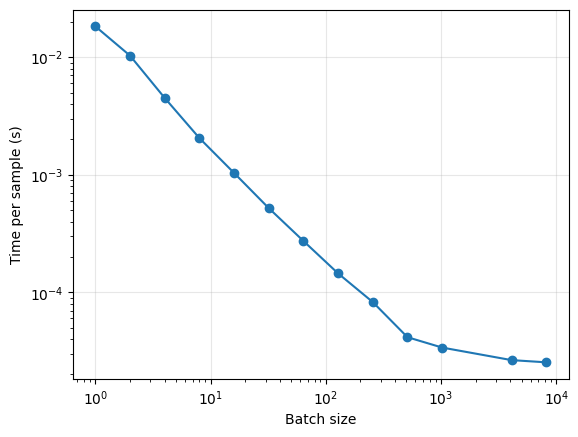

In [ ]:
q_tilde_bottom = torch.tensor(q_tilde_bottom, dtype=torch.float32, device=DEVICE)
q_tilde_top = torch.tensor(q_tilde_top, dtype=torch.float32, device=DEVICE)
ns = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
times = []
for n in ns:
    q = torch.tile(q_tilde_bottom, (n, 1))
    t = time.time()
    parameterization(q, jacobian=True)
    times.append(time.time() - t)

plt.loglog(ns, [t/n for t, n in zip(times, ns)], 'o-')
plt.xlabel('Batch size'); plt.ylabel('Time per sample (s)'); plt.grid(True, alpha=0.3)
plt.show()

## time per sample rapidly falls as we batch our inputs

## Planning with PRM

In [14]:
import scipy
def RandomConfig(n):
    q_tilde = np.zeros((n, 15))
    q_tilde[:, :7] = np.random.uniform(
        low=iiwa_analytic_ik.iiwa_limits_lower,
        high=iiwa_analytic_ik.iiwa_limits_upper,
        size=(n, 7),
    )
    q_tilde[:, 7:] = np.random.randn(n, 8)
    return q_tilde


def pose_7_from_fk(q):
    return pose_from_transform(iiwa_fk.FK(q))

def ValidityChecker(q_tildes):
    '''q_tildes is a (n, 15) shape batch for which we need to find all'''
    
    n = q_tildes.shape[0]
    bool_result = np.full(shape = n, fill_value=True)
    
    jac, q_full = parameterization(q_tildes, jacobian=True)
    jac_numpy = jac.detach().cpu().numpy()
    q_full_numpy = q_full.detach().cpu().numpy()

    targets = torch.func.vmap(q_to_ee_target)(q_full[:, :7]).detach().cpu().numpy()
    pose_7 = torch.func.vmap(pose_7_from_fk)(q_full[:, 7:]).detach().cpu().numpy()


    for i in range(n):
        if np.linalg.norm(pose_7[i, :3] - targets[i, :3]) > 0.1: bool_result[i] = False
        if 2 * np.arccos(np.clip(np.abs(np.dot(pose_7[i, 3:] , targets[i, 3:])), -1, 1)) > 0.2: bool_result[i] = False

        if (q_full_numpy[i, 7:] < iiwa_analytic_ik.iiwa_limits_lower).any(): bool_result[i] = False
        if (q_full_numpy[i, 7:] > iiwa_analytic_ik.iiwa_limits_upper).any(): bool_result[i] = False
        if not checker.CheckConfigCollisionFree(q_full_numpy[i]): bool_result[i] = False
        
        try:
            if np.linalg.svd(jac_numpy[i], compute_uv=False)[0] > 500:
                bool_result[i] = False
        except:
            bool_result[i] = False

    return bool_result
q_tilde_batch = torch.vstack([q_tilde_bottom, q_tilde_top])

validity = ValidityChecker(q_tilde_batch)
print(validity)

[ True  True]


/home/tangles/Urop/ikflow/.venv/lib/python3.10/site-packages/torch/utils/_device.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


In [ ]:
from src.prm import PRMOptions, PRM
prm_options = PRMOptions(check_size=3e-3, k_neighbors=10, num_vertices=1e5)
prm = PRM(RandomConfig, ValidityChecker)

prm.create_roadmap(start=q_tilde_bottom.detach().cpu().numpy(), goal=q_tilde_top.detach().cpu().numpy(), options=prm_options)

prm.find_path()


Sampling PRM proposals:   0%|          | 0/100000 [00:00<?, ?it/s]

/home/tangles/Urop/ikflow/.venv/lib/python3.10/site-packages/torch/utils/_device.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


Found 1090 valid random configurations.
Constructed k-NN graph with k=10 for 1092 nodes. Preparing edge checks...
Prepared 5467 edges for validation. Average intermediate points per edge: 1242.50


Validating edges:   0%|          | 0/5467 [00:00<?, ?it/s]

In [ ]:
# We also run randomized shortcutting to improve the paths at least a little bit.
np.random.seed(0)
shortcut_path = shortcut.shortcut(path.copy(), ValidityChecker, num_tries=1e2, check_size=rrt_options.check_size)

NameError: name 'path' is not defined

In [ ]:
rrt_traj_segments = [
    PiecewisePolynomial.CubicWithContinuousSecondDerivatives(
        np.array([float(i) - 1.0, float(i)]),
        np.array([shortcut_path[i-1], shortcut_path[i]]).T,
        np.zeros(15),
        np.zeros(15)
    )
    for i in range(1, len(shortcut_path))
]
rrt_traj = CompositeTrajectory(rrt_traj_segments)

In [ ]:
# Visualize the trajectory by sampling and animating it
import time

# Sample the trajectory at regular time intervals
t_start = rrt_traj.start_time()
t_end = rrt_traj.end_time()
num_samples = 1000
times = np.linspace(t_start, t_end, num_samples)

# Save the sampled trajectory so other notebooks or scripts can load it later.
q_tilde_samples = []
q_full_samples = []

# Animate the trajectory
for t in tqdm(times):
    q_tilde = rrt_traj.value(t).flatten()
    q_full = parameterization(q_tilde)
    q_tilde_samples.append(q_tilde.copy())
    q_full_samples.append(q_full.copy())
    plant.SetPositions(plant_context, q_full)
    diagram.ForcedPublish(context)
    time.sleep(0.01)  # Small delay to make animation viewable
    
    

q_tilde_samples = np.asarray(q_tilde_samples)
q_full_samples = np.asarray(q_full_samples)
output_dir = os.path.abspath(os.path.join(common.RepoDir(), "../ik-net-optimization/notebooks"))
np.save(os.path.join(output_dir, "rrt_q_tilde_samples.npy"), q_tilde_samples)
np.save(os.path.join(output_dir, "rrt_q_full_samples.npy"), q_full_samples)

print("Trajectory visualization complete!")

  0%|          | 0/1000 [00:00<?, ?it/s]

Trajectory visualization complete!


In [ ]:
t_start, t_end

(0.0, 20.0)

In [ ]:
new_times = np.linspace(14.5, 15, 300)
for t in tqdm(new_times):
    # print(t)
    q_tilde = rrt_traj.value(t).flatten()
    print(q_tilde[7:])
    q_full = parameterization(q_tilde)
    print(np.linalg.svd(parameterization(q_tilde, jacobian=True),compute_uv=False)[0])
    plant.SetPositions(plant_context, q_full)
    diagram.ForcedPublish(context)
    time.sleep(0.01)

  0%|          | 0/300 [00:00<?, ?it/s]

[-0.03370947  0.02677112  0.46455348 -0.71986584  0.11846374 -0.15517668
 -0.99715862 -0.67048828]
357.9023518834135
[-0.03375585  0.02674434  0.4645855  -0.71996382  0.11855767 -0.15522442
 -0.99737457 -0.67062059]
363.76968096321144
[-0.03380222  0.02671756  0.46461753 -0.72006179  0.1186516  -0.15527217
 -0.99759051 -0.6707529 ]
363.97996010648677
[-0.0338486   0.02669078  0.46464955 -0.72015975  0.11874552 -0.15531991
 -0.99780645 -0.67088521]
345.6365718592809
[-0.03389497  0.026664    0.46468157 -0.72025771  0.11883944 -0.15536765
 -0.99802237 -0.67101751]
343.6673711772573
[-0.03394133  0.02663723  0.46471358 -0.72035566  0.11893335 -0.15541539
 -0.99823827 -0.67114979]
355.9973588649503
[-0.0339877   0.02661046  0.4647456  -0.7204536   0.11902725 -0.15546312
 -0.99845415 -0.67128206]
363.5304644032417
[-0.03403405  0.02658369  0.46477761 -0.72055153  0.11912113 -0.15551084
 -0.99866999 -0.67141431]
335.13956367862835
[-0.0340804   0.02655692  0.46480961 -0.72064944  0.119215   

KeyboardInterrupt: 

In [ ]:
for t in tqdm(times):
    q_tilde = rrt_traj.value(t).flatten()
    q_full = parameterization(q_tilde)
    q_full_autodiff = np.full(14, AutoDiffXd(0));
    for i in range(len(q_full)):
        deriv = np.zeros(14)
        deriv[i] = 1
        q_full_autodiff[i] = AutoDiffXd(q_full[i], derivatives=deriv)
    pose = program_right.fk(q_full_autodiff)
    pose = np.hstack([pose[0], pose[1]])
    jac = np.zeros((7, 7))
    for i in range(7):
        jac[i, :] = pose[i].derivatives()[7:]
    
    print(np.linalg.svd(jac, compute_uv=False)[5])
       




  0%|          | 0/300 [00:00<?, ?it/s]

0.18850891278748053
0.189225583266086
0.19109696940802604
0.19360207750851713
0.19644519402338773
0.19924541756615025
0.20149505675820356
0.20295183364364622
0.2033944148678294
0.20407544692628052
0.20554723874345227
0.207444682700201
0.20934838641845982
0.21089659644578218
0.21210310206890437
0.2127463216906638
0.2128871357065745
0.212559601338939
0.2119663987245164
0.21129652970342808
0.2105462887066076
0.20970538002444067
0.20901307958898024
0.20856218514859054
0.2084465654862475
0.20807997152973343
0.2073592361485717
0.20640401927545451
0.20542019716284082
0.20451954396565972
0.20371793013987546
0.20325575077468874
0.20315150148032113
0.20234414740809534
0.19982944086540103
0.1972162592106449
0.19332496882174444
0.18842885825441896
0.18254912130806591
0.17868538082592825
0.178203494402525
0.17745847421853636
0.1762581994762461
0.17471861559198473
0.17309541707086096
0.1715857469507058
0.17035604260649873
0.16973436153032312
0.1696097414807625
0.1692266578472597
0.16863138376717046


In [ ]:
AutoDiffXd(1, derivatives=[1, 0]).derivatives

<bound method PyCapsule.derivatives of <AutoDiffXd 1.0 nderiv=2>>